In [21]:
import sys
import sklearn
import matplotlib
import keras
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import Dense, Input
from keras import optimizers
from sklearn import model_selection
from keras import regularizers
import matplotlib.pyplot as plt
from keras.layers import Dropout
from keras.callbacks import EarlyStopping

### Tratamento de Dados Básico

In [2]:
data = pd.read_csv('weatherAUS.csv')
data

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145455,2017-06-21,Uluru,2.8,23.4,0.0,NaN,NaN,E,31.0,SE,...,51.0,24.0,1024.6,1020.3,NaN,NaN,10.1,22.4,No,No
145456,2017-06-22,Uluru,3.6,25.3,0.0,NaN,NaN,NNW,22.0,SE,...,56.0,21.0,1023.5,1019.1,NaN,NaN,10.9,24.5,No,No
145457,2017-06-23,Uluru,5.4,26.9,0.0,NaN,NaN,N,37.0,SE,...,53.0,24.0,1021.0,1016.8,NaN,NaN,12.5,26.1,No,No
145458,2017-06-24,Uluru,7.8,27.0,0.0,NaN,NaN,SE,28.0,SSE,...,51.0,24.0,1019.4,1016.5,3.0,2.0,15.1,26.0,No,No


In [3]:
data = data.dropna().copy()
data

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
6049,2009-01-01,Cobar,17.9,35.2,0.0,12.0,12.3,SSW,48.0,ENE,...,20.0,13.0,1006.3,1004.4,2.0,5.0,26.6,33.4,No,No
6050,2009-01-02,Cobar,18.4,28.9,0.0,14.8,13.0,S,37.0,SSE,...,30.0,8.0,1012.9,1012.1,1.0,1.0,20.3,27.0,No,No
6052,2009-01-04,Cobar,19.4,37.6,0.0,10.8,10.6,NNE,46.0,NNE,...,42.0,22.0,1012.3,1009.2,1.0,6.0,28.7,34.9,No,No
6053,2009-01-05,Cobar,21.9,38.4,0.0,11.4,12.2,WNW,31.0,WNW,...,37.0,22.0,1012.7,1009.1,1.0,5.0,29.1,35.6,No,No
6054,2009-01-06,Cobar,24.2,41.0,0.0,11.2,8.4,WNW,35.0,NW,...,19.0,15.0,1010.7,1007.4,1.0,6.0,33.6,37.6,No,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
142298,2017-06-20,Darwin,19.3,33.4,0.0,6.0,11.0,ENE,35.0,SE,...,63.0,32.0,1013.9,1010.5,0.0,1.0,24.5,32.3,No,No
142299,2017-06-21,Darwin,21.2,32.6,0.0,7.6,8.6,E,37.0,SE,...,56.0,28.0,1014.6,1011.2,7.0,0.0,24.8,32.0,No,No
142300,2017-06-22,Darwin,20.7,32.8,0.0,5.6,11.0,E,33.0,E,...,46.0,23.0,1015.3,1011.8,0.0,0.0,24.8,32.1,No,No
142301,2017-06-23,Darwin,19.5,31.8,0.0,6.2,10.6,ESE,26.0,SE,...,62.0,58.0,1014.9,1010.7,1.0,1.0,24.8,29.2,No,No


In [4]:
data['Date'] = pd.to_datetime(data['Date'])
data['Month'] = data['Date'].dt.month
data = data.drop(columns='Date').copy()

data.loc[:,'RainToday'] = data['RainToday'].map({'No': 0, 'Yes': 1})
data.loc[:,'RainTomorrow'] = data['RainTomorrow'].map({'No': 0, 'Yes': 1})

data['RainToday'] = data['RainToday'].astype(int)
data['RainTomorrow'] = data['RainTomorrow'].astype(int)

data['PressureChange'] = data['Pressure3pm'] - data['Pressure9am']
data['HumidityChange'] = data['Humidity3pm'] - data['Humidity9am']
data['TempChange'] = data['Temp3pm'] - data['Temp9am']
data['TempRange'] = data['MaxTemp'] - data['MinTemp']

data

,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,...,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow,Month,PressureChange,HumidityChange,TempChange,TempRange
6049,Cobar,17.9,35.2,0.0,12.0,12.3,SSW,48.0,ENE,SW,...,5.0,26.6,33.4,0,0,1,-1.9,-7.0,6.8,17.3
6050,Cobar,18.4,28.9,0.0,14.8,13.0,S,37.0,SSE,SSE,...,1.0,20.3,27.0,0,0,1,-0.8,-22.0,6.7,10.5
6052,Cobar,19.4,37.6,0.0,10.8,10.6,NNE,46.0,NNE,NNW,...,6.0,28.7,34.9,0,0,1,-3.1,-20.0,6.2,18.2
6053,Cobar,21.9,38.4,0.0,11.4,12.2,WNW,31.0,WNW,WSW,...,5.0,29.1,35.6,0,0,1,-3.6,-15.0,6.5,16.5
6054,Cobar,24.2,41.0,0.0,11.2,8.4,WNW,35.0,NW,WNW,...,6.0,33.6,37.6,0,0,1,-3.3,-4.0,4.0,16.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
142298,Darwin,19.3,33.4,0.0,6.0,11.0,ENE,35.0,SE,NE,...,1.0,24.5,32.3,0,0,6,-3.4,-31.0,7.8,14.1
142299,Darwin,21.2,32.6,0.0,7.6,8.6,E,37.0,SE,SE,...,0.0,24.8,32.0,0,0,6,-3.4,-28.0,7.2,11.4
142300,Darwin,20.7,32.8,0.0,5.6,11.0,E,33.0,E,W,...,0.0,24.8,32.1,0,0,6,-3.5,-23.0,7.3,12.1
142301,Darwin,19.5,31.8,0.0,6.2,10.6,ESE,26.0,SE,NNW,...,1.0,24.8,29.2,0,0,6,-4.2,-4.0,4.4,12.3


In [5]:
X = data.drop(['RainTomorrow'], axis = 1)
y = data['RainTomorrow']

X_treino_df, X_teste_df, y_treino_df, y_teste_df = train_test_split(X, y, random_state = 42, test_size = 0.2)
X_treino_df, X_val_df, y_treino_df, y_val_df = train_test_split(X_treino_df, y_treino_df, random_state = 42, test_size = 0.2)

In [6]:
colunas_categoricas = ['Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm', 'Month']

ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

X_treino_ohe = ohe.fit_transform(X_treino_df[colunas_categoricas])
X_val_ohe  = ohe.transform(X_val_df[colunas_categoricas])
X_teste_ohe  = ohe.transform(X_teste_df[colunas_categoricas])

treino_ohe_df = pd.DataFrame(X_treino_ohe, columns = ohe.get_feature_names_out(colunas_categoricas), index = X_treino_df.index)
val_ohe_df = pd.DataFrame(X_val_ohe, columns = ohe.get_feature_names_out(colunas_categoricas), index = X_val_df.index)
teste_ohe_df = pd.DataFrame(X_teste_ohe, columns = ohe.get_feature_names_out(colunas_categoricas), index = X_teste_df.index)

data_treino = pd.concat([X_treino_df.drop(columns=colunas_categoricas), treino_ohe_df], axis = 1)
data_val = pd.concat([X_val_df.drop(columns=colunas_categoricas), val_ohe_df], axis = 1)
data_teste = pd.concat([X_teste_df.drop(columns=colunas_categoricas), teste_ohe_df], axis = 1)

In [7]:
data_treino

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,...,Month_3,Month_4,Month_5,Month_6,Month_7,Month_8,Month_9,Month_10,Month_11,Month_12
84362,14.7,20.0,0.4,2.8,0.0,31.0,4.0,4.0,90.0,89.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
123396,17.8,24.4,1.6,4.0,0.0,31.0,7.0,13.0,97.0,82.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
93789,24.5,27.4,0.2,5.4,0.4,37.0,19.0,17.0,88.0,85.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
141899,24.8,35.1,0.0,6.6,10.9,39.0,15.0,19.0,58.0,42.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10505,18.9,27.3,0.0,4.4,7.6,65.0,15.0,44.0,67.0,63.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85740,11.1,19.6,0.0,2.4,3.3,17.0,6.0,7.0,74.0,89.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
118486,8.3,18.3,0.0,2.4,8.6,44.0,22.0,24.0,68.0,46.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
138204,19.7,40.3,0.0,15.8,10.6,41.0,31.0,15.0,10.0,7.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
68923,7.2,12.1,2.0,1.4,0.1,26.0,13.0,17.0,86.0,82.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


In [8]:
data_val

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,...,Month_3,Month_4,Month_5,Month_6,Month_7,Month_8,Month_9,Month_10,Month_11,Month_12
95718,24.2,30.0,0.0,9.6,12.0,37.0,20.0,30.0,59.0,56.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
32238,21.7,28.7,0.0,8.0,6.9,52.0,9.0,9.0,67.0,66.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
87244,23.7,30.9,0.0,6.0,11.7,30.0,11.0,15.0,69.0,66.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
33794,16.1,20.4,0.0,10.2,0.5,65.0,15.0,20.0,81.0,74.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
67365,15.7,17.1,36.2,4.8,0.0,76.0,17.0,48.0,96.0,93.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71076,11.3,23.1,0.0,3.6,7.5,28.0,13.0,6.0,80.0,51.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
87399,19.5,25.9,0.0,4.8,0.8,37.0,17.0,20.0,74.0,76.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
118030,16.2,25.3,0.0,8.4,6.6,35.0,13.0,20.0,59.0,52.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
38971,20.3,33.2,0.0,9.4,5.8,59.0,30.0,26.0,43.0,25.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [9]:
data_teste

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,...,Month_3,Month_4,Month_5,Month_6,Month_7,Month_8,Month_9,Month_10,Month_11,Month_12
47050,7.7,24.2,0.0,4.8,13.2,39.0,9.0,20.0,67.0,39.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
139158,18.3,30.8,0.0,9.8,10.8,44.0,26.0,24.0,18.0,8.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
23488,14.4,19.4,4.8,5.8,10.1,61.0,30.0,33.0,69.0,62.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
32117,11.8,18.6,0.0,4.0,2.5,56.0,20.0,28.0,50.0,42.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
122837,10.8,19.4,8.8,4.4,11.1,31.0,15.0,15.0,56.0,48.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65843,8.6,20.6,0.2,3.0,10.3,28.0,17.0,7.0,71.0,50.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
100882,5.1,15.0,4.6,6.6,7.0,39.0,15.0,20.0,77.0,74.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
70986,-1.3,15.2,0.0,2.2,8.6,33.0,9.0,17.0,77.0,37.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
39109,9.6,23.5,0.0,3.4,10.7,33.0,13.0,17.0,56.0,24.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [10]:
X_treino = np.array(data_treino)
X_val = np.array(data_val)
X_teste = np.array(data_teste)

y_treino = np.array(y_treino_df)
y_val = np.array(y_val_df)
y_teste = np.array(y_teste_df)

scaler = MinMaxScaler()

X_treino = scaler.fit_transform(X_treino)
X_val = scaler.fit_transform(X_val)
X_teste  = scaler.transform(X_teste)

In [11]:
data_completo = pd.concat([data_treino, data_teste])
data_completo = pd.concat([data_completo, data_val])

Ct = data_completo.shape[0]
d = data_completo.shape[1]

n = (Ct - 10) / (10 * (d + 2))
n = int(n)

n

51

In [16]:
model = Sequential()

# Entrada
model.add(Input(shape=(d,)))

# Camadas escondidas
model.add(Dense(51, kernel_initializer='normal', kernel_regularizer=regularizers.l2(0.01), activation='relu'))
model.add(Dropout(0.2))
# Camada de saída
model.add(Dense(1, kernel_initializer='normal', activation='sigmoid'))

# Obtém os pesos iniciais da rede
initial_weights = model.get_weights()

es = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=10)
# Compila o modelo
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy', ])

print(model.summary())

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 51)             │         5,508 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 51)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            52 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,560 (21.72 KB)

 Trainable params: 5,560 (21.72 KB)

 Non-trainable params: 0 (0.00 B)

None


In [22]:
model.set_weights(initial_weights)
history = model.fit(X_treino, y_treino, epochs=100, batch_size=64, validation_data=(X_val, y_val), callbacks=[es])

Epoch 1/100
565/565 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.7963 - loss: 0.5127 - val_accuracy: 0.8316 - val_loss: 0.4275
Epoch 2/100
565/565 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.8381 - loss: 0.3992 - val_accuracy: 0.8377 - val_loss: 0.3868
Epoch 3/100
565/565 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.8460 - loss: 0.3764 - val_accuracy: 0.8394 - val_loss: 0.3754
Epoch 4/100
565/565 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.8472 - loss: 0.3700 - val_accuracy: 0.8411 - val_loss: 0.3724
Epoch 5/100
565/565 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.8484 - loss: 0.3662 - val_accuracy: 0.8291 - val_loss: 0.3902
Epoch 6/100
565/565 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.8461 - loss: 0.3664 - val_accuracy: 0.8433 - val_loss: 0.3663
Epoch 7/100
565/565 ━━━━━━━━━━━━━━━━━━━━ 22s 36ms/step - accuracy: 0.8488 - loss: 0.3629 - val_accuracy: 0.8453 - val_loss: 0.3672
Epoch 8/100
565/565 ━━━━━━━━━━━━━━━━━━━━ 17s 31ms/step - accuracy: 0.8481 - loss: 0.3631 - val_

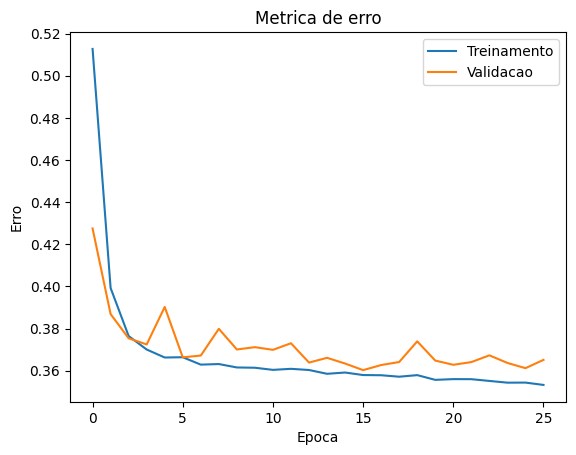

--> E_val - E_in = 0.0202
--> Acuracia (treino): 0.8568
--> Acuracia (validacao): 0.8415
--> acc_train - acc_test = 0.0154


In [23]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Metrica de erro')
plt.ylabel('Erro')
plt.xlabel('Epoca')
plt.legend(['Treinamento', 'Validacao'])
plt.show()

# Obtendo a acuracia no conjunto de treinamento
E_in, acc_train = model.evaluate(X_treino, y_treino, batch_size=64, verbose=0)

# Obtendo a acuracia no conjunto de validacao
E_val, acc_val = model.evaluate(X_val, y_val, batch_size=64, verbose=0)

print(f"--> E_val - E_in = {E_val - E_in:.4f}")
print(f'--> Acuracia (treino): {acc_train:.4f}')
print(f'--> Acuracia (validacao): {acc_val:.4f}')
print(f"--> acc_train - acc_test = {acc_train - acc_val:.4f}")

In [24]:
y_prob = model.predict(X_teste)

y_pred = (y_prob > 0.5).astype(int)

print(classification_report(y_teste, y_pred))

353/353 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
              precision    recall  f1-score   support

           0       0.90      0.91      0.91      8799
           1       0.67      0.65      0.66      2485

    accuracy                           0.85     11284
   macro avg       0.79      0.78      0.78     11284
weighted avg       0.85      0.85      0.85     11284



In [ ]:
def ModelagemRC(X_train, y_train, X_test, Modelo):
    
    Modelo.fit(X_train, y_train)
    
    return Modelo.predict(X_test)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

modelo = RandomForestClassifier(random_state=42) # inicializando o modelo com random_state = 42

random_forest_predict = ModelagemRC(X_treino, y_treino, X_teste, modelo) # treinando o modelo e realizando o predict

print(classification_report(y_teste, random_forest_predict)) # exibindo os resultados

              precision    recall  f1-score   support

           0       0.90      0.92      0.91      8763
           1       0.69      0.62      0.65      2466

    accuracy                           0.86     11229
   macro avg       0.79      0.77      0.78     11229
weighted avg       0.85      0.86      0.85     11229

